# NFW Halo Equilibrium

This tutorial demonstrates how to generate an NFW dark matter halo in virial equilibrium
using `mkNFW_galpy`, run a self-gravity simulation, and verify that the system remains
in equilibrium over several dynamical times.

The NFW potential used here has $v_c(8\,\mathrm{kpc}) = 220\,\mathrm{km/s}$ (galpy default),
with particles sampled out to $r_{\max} = 80\,\mathrm{kpc}$ (10 scale radii).

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [6]:
from ezfalcon.tools import mkNFW_galpy
from ezfalcon.util.units import G_INTERNAL, KMS_TO_KPCGYR
from galpy.potential import NFWPotential

# Galpy default unit scales
RO, VO = 8.0, 220.0  # kpc, km/s

# NFW scale radius = RO = 8 kpc (galpy default, a=1 in natural units)
# Truncation radius for DF sampling
rmax_ro = 10.0          # in galpy natural units (= 10 * 8 = 80 kpc)
rmax_kpc = rmax_ro * RO # kpc



nfw = NFWPotential(rmax=rmax)
M_total = nfw.mass(rmax_ro)#nfw_enclosed_mass(rmax_kpc)
print(f'NFW scale radius:   {RO:.0f} kpc')
print(f'Truncation radius:  {rmax_kpc:.0f} kpc')
print(f'Enclosed mass:      {M_total:.3e} Msun')

# Sample particles
N = 10000
np.random.seed(42)
pos, vel, masses = mkNFW_galpy(
    m=M_total,
    n=N,
    nfw_df_kwargs={'rmax': rmax_ro},
)

r = np.linalg.norm(pos, axis=1)
v = np.linalg.norm(vel, axis=1)
print(f'\nParticle radii:  median = {np.median(r):.1f} kpc,  max = {r.max():.1f} kpc')
print(f'Particle speeds: rms    = {np.sqrt(np.mean(v**2)):.1f} km/s')
print(f'Crossing time:   t_cross ~ {np.median(r) / (np.sqrt(np.mean(v**2)) * KMS_TO_KPCGYR):.2f} Gyr')

NameError: name 'rmax' is not defined

## Set Up and Run the Simulation

In [9]:
from ezfalcon.simulation import Sim

sim = Sim()
sim.add_particles('halo', pos, vel, mass=masses)

sim.run(
    t_end=2.0,      # Gyr  (~6 crossing times)
    dt=0.001,       # Gyr
    dt_out=0.02,    # Gyr  (100 snapshots)
    eps=1.0,        # kpc  (softening length)
    theta=0.5,
    kernel=1,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:51<00:00, 38.85it/s]


## Diagnostics

A system in virial equilibrium should conserve total energy. The energy diagnostic below
plots the fractional energy error $\Delta E / |E_0|$ over time — a flat line indicates
the integration is well-behaved and the halo is not collapsing or evaporating.

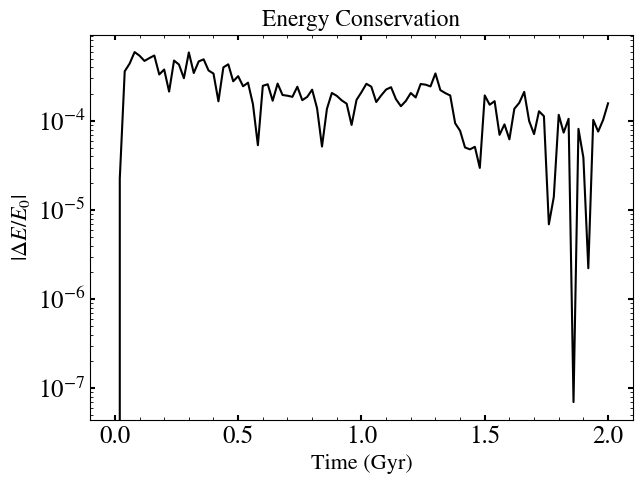

In [10]:
sim.plot_energy_diagnostic()

In [11]:
# Cross-check with direct summation (slower but avoids tree approximation errors)
sim.plot_energy_diagnostic(method='direct_C', eps=1.0, nsnap=20)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1637: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$|\Delta E / E_0|$")

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1672: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$|\Delta p / p_0|$")



KeyboardInterrupt: 

<Figure size 700x500 with 0 Axes>

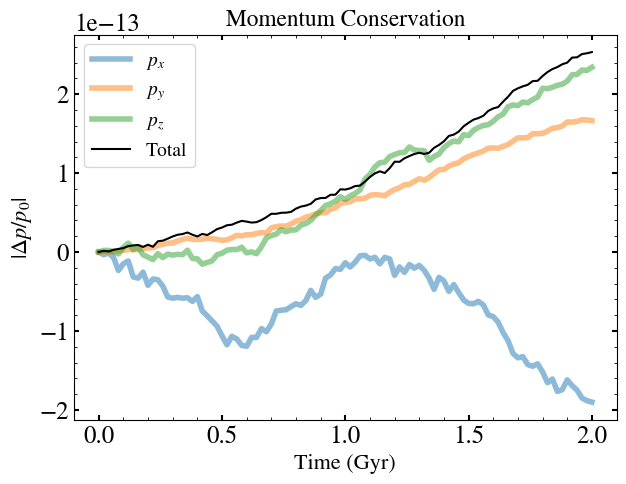

In [12]:
sim.plot_momentum_diagnostic()

## Particle Distribution

As a visual check, the projected particle distribution at $t=0$ and $t=t_{\rm end}$
should look statistically similar — no collapse or expansion.

/tmp/ipykernel_2571338/1789941832.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



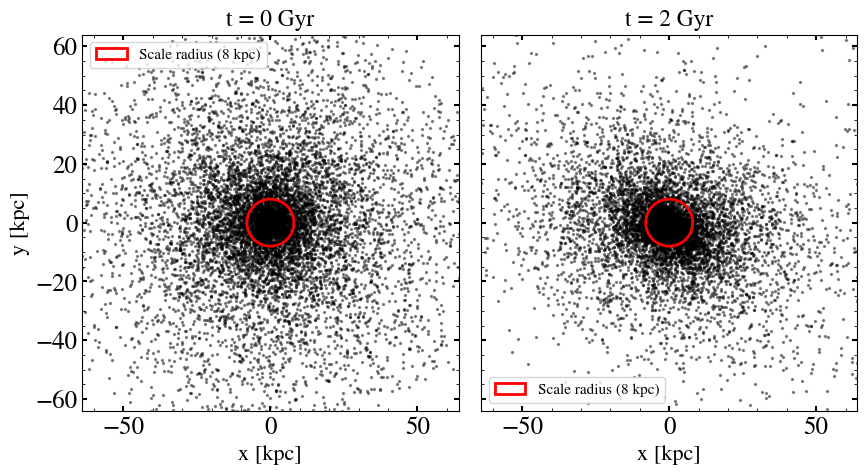

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True,
                         gridspec_kw={'wspace': 0.06})

# Initial positions
axes[0].scatter(sim.x(0), sim.y(0), s=2, c='k', alpha=0.4)
circle = plt.Circle((0, 0), RO, color='r', fill=False, label='Scale radius (8 kpc)', lw=2)
axes[0].add_artist(circle)
axes[0].set_xlim(-rmax_kpc * 0.8, rmax_kpc * 0.8)
axes[0].set_ylim(-rmax_kpc * 0.8, rmax_kpc * 0.8)
axes[0].set_xlabel('x [kpc]')
axes[0].set_ylabel('y [kpc]')
axes[0].set_title('t = 0 Gyr')
axes[0].set_aspect('equal')
axes[0].legend(fontsize=11)

# Final positions
axes[1].scatter(sim.x(-1), sim.y(-1), s=2, c='k', alpha=0.4)
circle = plt.Circle((0, 0), RO, color='r', fill=False, label='Scale radius (8 kpc)', lw=2)
axes[1].add_artist(circle)
axes[1].set_xlabel('x [kpc]')
axes[1].set_title(f't = 2 Gyr')
axes[1].set_aspect('equal')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

In [15]:
len(sim.times)

101

In [18]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = len(sim.x())//2  # t_end=100, dt_out=10 -> snapshots at 0,10,...,100

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
sc = ax_anim.scatter(sim.x(0), sim.y(0), s=1, c='k', alpha=0.5)

ax_anim.set_xlim(-60, 60)
ax_anim.set_ylim(-60, 60)
ax_anim.set_xlabel('x [kpc]', fontsize=20)
ax_anim.set_ylabel('y [kpc]', fontsize=20)
ax_anim.set_aspect('equal')
title = ax_anim.set_title('t = 0', fontsize=22)

def update(i):
    i *= 2
    sc.set_offsets(list(zip(sim.x(i), sim.y(i))))
    title.set_text(f't = {sim.times[i]*1000:.0f} Myr')
    return sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=100, blit=False)
plt.close(fig_anim)
fig_anim.tight_layout()
anim.save(
    'nfw_evolution.gif',
    writer='pillow',
    fps=10
)